In [ ]:
import os
import torch
import torchvision
from torch.utils.data import random_split
import torchvision.models as models
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
data_dir  = '/content/drive/MyDrive/LetsPrompt Fiverr Projects/Order 007 - Garbage Detection/Garbage_Classification_Dataset_LPD'

classes = os.listdir(data_dir)
print(classes)

['biodegradables', 'papers', 'plastics', 'cardboards', 'glass', 'metals']


In [ ]:
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms

transformations = transforms.Compose([transforms.Resize((256, 256)), transforms.ToTensor()])

dataset = ImageFolder(data_dir, transform = transformations)

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

def show_sample(img, label):
    print("Label:", dataset.classes[label], "(Class No: "+ str(label) + ")")
    plt.imshow(img.permute(1, 2, 0))

Label: biodegradables (Class No: 0)


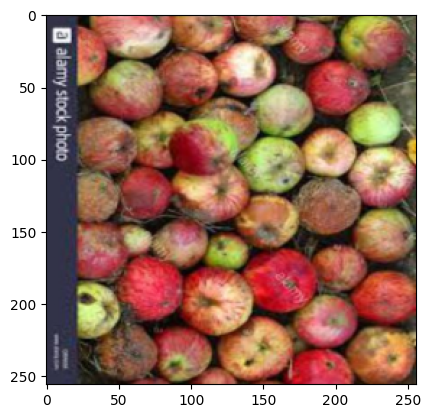

In [ ]:
img, label = dataset[1]
show_sample(img, label)

In [ ]:
random_seed = 42
torch.manual_seed(random_seed)

In [ ]:
from torch.utils.data import random_split

# Assuming dataset is your torch Dataset object
total_length = len(dataset)
print(total_length)
train_length = 13892
val_length = 1736
test_length = 1737

# Check if the sum of lengths matches the total length of the dataset
if train_length + val_length + test_length != total_length:
    raise ValueError("Sum of lengths does not match the total length of the dataset!")

# Perform random split
train_ds, val_ds, test_ds = random_split(dataset, [train_length, val_length, test_length])

# Check the lengths of each split
len(train_ds), len(val_ds), len(test_ds)

17365


(13892, 1736, 1737)

In [ ]:
from torch.utils.data.dataloader import DataLoader
batch_size = 32

In [ ]:
train_dl = DataLoader(train_ds, batch_size, shuffle = True, num_workers = 4, pin_memory = True)
val_dl = DataLoader(val_ds, batch_size*2, num_workers = 4, pin_memory = True)

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [ ]:
from torchvision.utils import make_grid

def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(make_grid(images, nrow = 16).permute(1, 2, 0))
        break

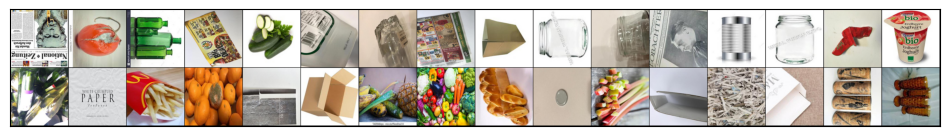

In [ ]:
show_batch(train_dl)

In [ ]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.tensor(torch.sum(preds == labels).item() / len(preds))

class ImageClassificationBase(nn.Module):
    def training_step(self, batch):
        images, labels = batch
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss

    def validation_step(self, batch):
        images, labels = batch
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss.detach(), 'val_acc': acc}

    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}

    def epoch_end(self, epoch, result):
        print("Epoch {}: train_loss: {:.4f}, val_loss: {:.4f}, val_acc: {:.4f}".format(
            epoch+1, result['train_loss'], result['val_loss'], result['val_acc']))

In [ ]:
class ResNet(ImageClassificationBase):
    def __init__(self):
        super().__init__()
        # Use a pretrained model
        self.network = models.resnet50(pretrained=True)
        # Replace last layer
        num_ftrs = self.network.fc.in_features
        self.network.fc = nn.Linear(num_ftrs, len(dataset.classes))

    def forward(self, xb):
        return torch.sigmoid(self.network(xb))

model = ResNet()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 105MB/s]


In [ ]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [ ]:
device = get_default_device()
device

device(type='cuda')

In [ ]:
train_dl = DeviceDataLoader(train_dl, device)
val_dl = DeviceDataLoader(val_dl, device)
to_device(model, device)

ResNet(
  (network): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (

In [ ]:
@torch.no_grad()
def evaluate(model, val_loader):
    model.eval()
    outputs = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(outputs)

def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        # Training Phase
        model.train()
        train_losses = []
        for batch in train_loader:
            loss = model.training_step(batch)
            train_losses.append(loss)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        # Validation phase
        result = evaluate(model, val_loader)
        result['train_loss'] = torch.stack(train_losses).mean().item()
        model.epoch_end(epoch, result)
        history.append(result)
    return history

In [ ]:
model = to_device(ResNet(), device)

In [ ]:
evaluate(model, val_dl)

{'val_loss': 1.7955470085144043, 'val_acc': 0.1618303507566452}

In [ ]:
from tqdm import tqdm

num_epochs = 5
opt_func = torch.optim.Adam
lr = 5.5e-5

history = fit(num_epochs, lr, model, tqdm(train_dl), tqdm(val_dl), opt_func)

100%|██████████| 435/435 [10:52<00:00,  1.50s/it]

100%|██████████| 28/28 [11:05<00:00, 23.79s/it]

Epoch 1: train_loss: 1.1875, val_loss: 1.1047, val_acc: 0.9408


Epoch 2: train_loss: 1.0900, val_loss: 1.0824, val_acc: 0.9626
Epoch 3: train_loss: 1.0720, val_loss: 1.0951, val_acc: 0.9459
Epoch 4: train_loss: 1.0662, val_loss: 1.0806, val_acc: 0.9576
Epoch 5: train_loss: 1.0592, val_loss: 1.0804, val_acc: 0.9637


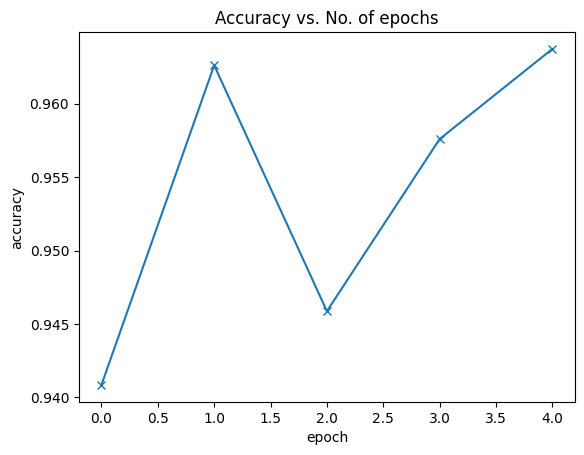

In [ ]:
def plot_accuracies(history):
    accuracies = [x['val_acc'] for x in history]
    plt.plot(accuracies, '-x')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('Accuracy vs. No. of epochs');

plot_accuracies(history)

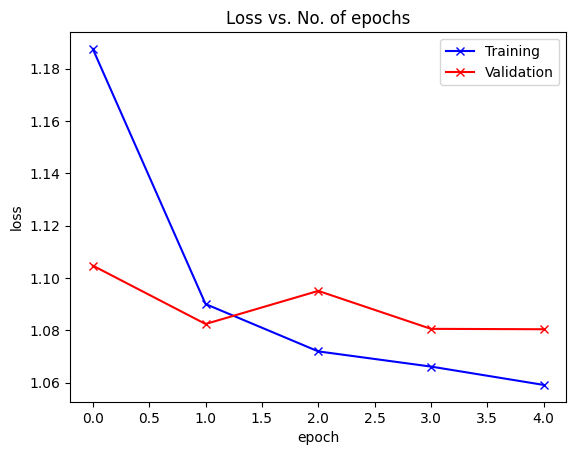

In [ ]:
def plot_losses(history):
    train_losses = [x.get('train_loss') for x in history]
    val_losses = [x['val_loss'] for x in history]
    plt.plot(train_losses, '-bx')
    plt.plot(val_losses, '-rx')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.legend(['Training', 'Validation'])
    plt.title('Loss vs. No. of epochs');

plot_losses(history)

In [ ]:
def predict_image(img, model):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    prob, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return dataset.classes[preds[0].item()]

Label: cardboards , Predicted: cardboards


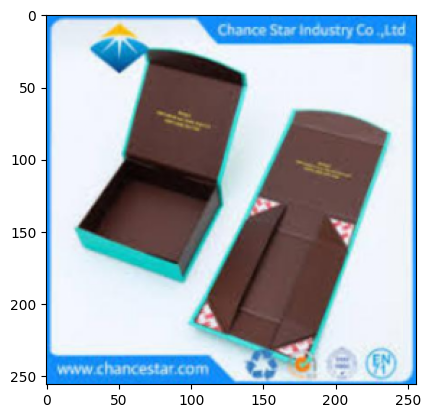

In [ ]:
img, label = test_ds[7]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

Label: glass , Predicted: glass


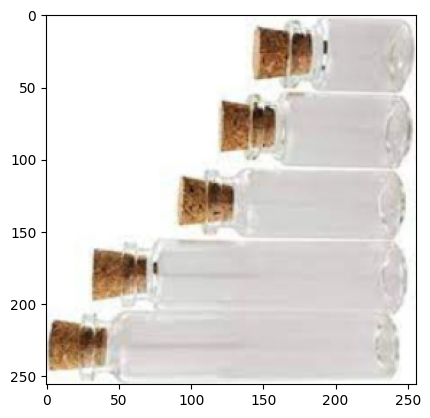

In [ ]:
img, label = test_ds[2]
plt.imshow(img.permute(1, 2, 0))
print('Label:', dataset.classes[label], ', Predicted:', predict_image(img, model))

In [ ]:
import pandas as pd

actual_labels = []
predicted_labels = []

# Iterate through test dataset
for img, label in test_ds:
    # Get the actual label
    actual_label = dataset.classes[label]
    # Predict the label for the image
    predicted_label = predict_image(img, model)
    # Append the actual and predicted labels to the lists
    actual_labels.append(actual_label)
    predicted_labels.append(predicted_label)

# Create a DataFrame from the lists
test_result_df = pd.DataFrame({'Actual': actual_labels, 'Predicted': predicted_labels})

In [ ]:
test_result_df

,Actual,Predicted
0,glass,biodegradables
1,glass,plastics
2,cardboards,cardboards
3,plastics,plastics
4,metals,metals
5,plastics,plastics
6,cardboards,cardboards
7,biodegradables,biodegradables
8,plastics,glass
9,cardboards,cardboards


In [ ]:
import torch

def test_accuracy(test_ds, model):
    correct = 0
    total = 0

    for img, label in test_ds:
        predicted_label = predict_image(img, model)
        if predicted_label == dataset.classes[label]:
            correct += 1
        total += 1

    # Calculate accuracy
    accuracy = correct / total
    return accuracy

accuracy = test_accuracy(test_ds, model)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

KeyboardInterrupt: 

In [ ]:
%cd /content/drive/MyDrive/LetsPrompt Fiverr Projects/Order 007 - Garbage Detection/Resnet_Inference_Model

/content/drive/MyDrive/LetsPrompt Fiverr Projects/Order 007 - Garbage Detection/Resnet_Inference_Model


In [ ]:
torch.save(model.state_dict(), 'complete_data_trained_resnet_model.pth')

### Inference Code

In [ ]:
# model = to_device(ResNet(), device)
# model.load_state_dict(torch.load('/content/drive/MyDrive/LetsPrompt Fiverr Projects/Order 007 - Garbage Detection/Resnet_Inference_Model/trained_resnet_model.pth'))
# model.eval()

In [ ]:
loaded_model = model

In [ ]:
def predict_image(img, model):
    # Convert to a batch of 1
    xb = to_device(img.unsqueeze(0), device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    prob, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return dataset.classes[preds[0].item()]

In [ ]:
from PIL import Image
from pathlib import Path

def predict_external_image(image_name):
    image = Image.open(Path('/' + image_name))

    example_image = transformations(image)
    plt.imshow(example_image.permute(1, 2, 0))
    print("Prediction : ", predict_image(example_image, loaded_model) + ".")

Prediction :  cardboards.


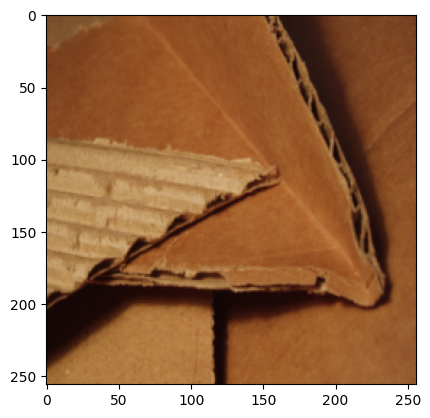

In [ ]:
predict_external_image('/content/drive/MyDrive/LetsPrompt Fiverr Projects/Order 007 - Garbage Detection/Test_Images/R.jpg')